In [ ]:
SAMPLE_WAV_PATH = "./sample.wav"

In [ ]:
# 1. IPython
from IPython.display import Audio, display

display(Audio(SAMPLE_WAV_PATH))

In [ ]:
# 2. Soundfile
import soundfile as sf

# Read
audio, sample_rate = sf.read(SAMPLE_WAV_PATH)
print(audio, audio.shape)
print(sample_rate)

# Write

sf.write("./audio.flac", audio, sample_rate)

[[-3.05175781e-05  0.00000000e+00]
 [ 9.15527344e-05  0.00000000e+00]
 [-1.52587891e-04  0.00000000e+00]
 ...
 [-6.10351562e-05  6.10351562e-05]
 [ 0.00000000e+00 -6.10351562e-05]
 [ 6.10351562e-05  3.05175781e-05]] (526073, 2)
44100


In [ ]:
# 3. Wave
import wave

wave_object = wave.open(SAMPLE_WAV_PATH, "r")

print(wave_object.getnchannels())
print(wave_object.getsampwidth())
print(wave_object.getframerate())
print(wave_object.getnframes())
print(wave_object.getparams())
print(wave_object.getnframes() / 16000)

frames = wave_object.readframes(wave_object.getnframes())
sample_rate = wave_object.getframerate()

wave_object.close()

2
2
44100
526073
_wave_params(nchannels=2, sampwidth=2, framerate=44100, nframes=526073, comptype='NONE', compname='not compressed')
32.8795625


In [ ]:
obj = wave.open("./wave_write.flac", "w")
obj.setnchannels(1)
obj.setsampwidth(2)
obj.setframerate(sample_rate)
obj.writeframes(frames)
obj.close()

In [ ]:
from pydub import AudioSegment

audio = AudioSegment.from_wav(SAMPLE_WAV_PATH)
audio_up = audio + 25

audio_stretch = audio * 2

audio_fin = audio.fade_in(10000)

audio_fout = audio.fade_out(10000)

audio_reverse = audio.reverse()

In [ ]:
first3_sec = audio[:(3*1000)]
last3_sec = audio[-(3*1000):]

concat_audio = first3_sec + last3_sec
display(concat_audio)

In [ ]:
concat_audio.export("concat_audio.mp3", format="mp3")

<_io.BufferedRandom name='concat_audio.mp3'>

In [ ]:
import librosa

audio, sample_rate = librosa.load(SAMPLE_WAV_PATH)
print(audio, audio.shape)
print(sample_rate)

[-1.2256205e-06  6.3888729e-06 -8.4303319e-06 ... -1.2530327e-06
 -3.6254823e-06  1.0569282e-05] (263037,)
22050


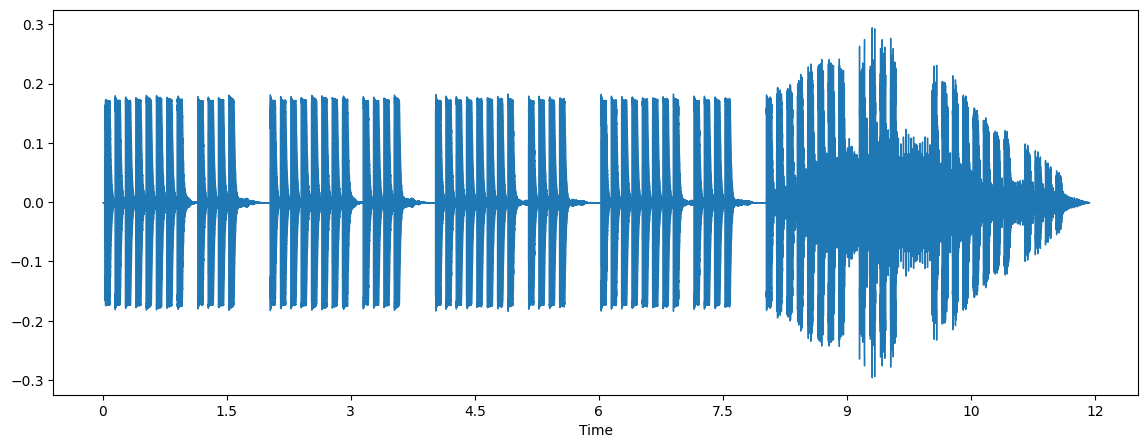

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
librosa.display.waveshow(audio, sr=sample_rate)
#

In [ ]:
librosa.effects.pitch_shift(audio, sr=sample_rate, n_steps=12)

array([-3.1137466e-04, -4.3543056e-04, -3.5154633e-04, ...,
        4.3819025e-05,  4.6978545e-05,  4.7635454e-05], dtype=float32)

In [ ]:
display(Audio(librosa.effects.time_stretch(audio, rate=0.5), rate=sample_rate))

In [ ]:
import numpy as np

def white_noise(frames, factor):
  noise = np.random.normal(0, frames.std(), frames.size)
  return frames +(noise * factor)

white = white_noise(audio, 0.1)

In [ ]:
def random_gain(frames, min_gain_factor, max_gain_factor):
  gain = np.random.uniform(min_gain_factor, max_gain_factor)
  return frames * gain

random = random_gain(audio, 0.5, 1.5)

In [ ]:
import torch
import torchaudio

In [ ]:
audio, sr = torchaudio.load(SAMPLE_WAV_PATH)

In [ ]:
def _plot(waveform, sample_rate, title):
  waveform = waveform.numpy()

  num_channels, num_frames = waveform.shape
  time_axis = torch.arange(0, num_frames) / sample_rate
  figure, axes = plt.subplots(num_channels, 1)

  # mono
  if num_channels == 1:
    axes = [axes]

  for c in range(num_channels):
    if title == "waveform":
      axes[c].plot(time_axis, waveform[c], linewidth=1)
    else:
      axes[c].specgram(waveform[c], Fs=sample_rate)

def plot_waveform (waveform, sample_rate):
  _plot(waveform, sample_rate, "waveform")

def plot_specgram (waveform, sample_rate):
  _plot(waveform, sample_rate, "specgram")

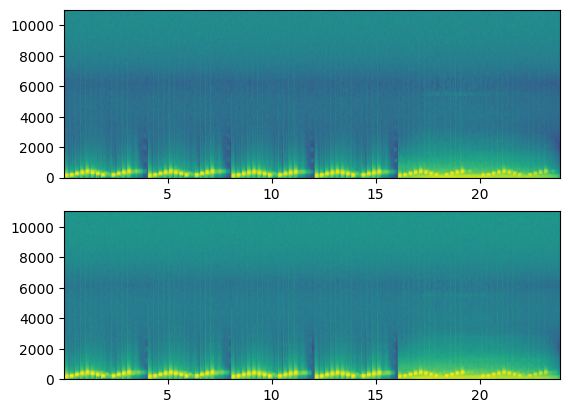

In [ ]:
plot_specgram(audio, sample_rate)

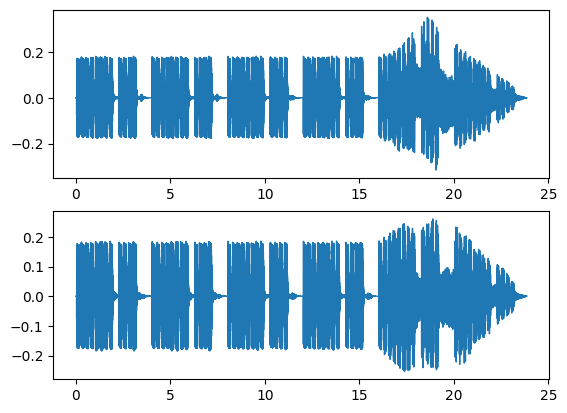

In [ ]:
plot_waveform(audio, sample_rate)